<a href="https://colab.research.google.com/github/OptimizationExpert/Pyomo/blob/main/TDCPVRP_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Developed by Alireza Soroudi
alireza.soroudi@gmail.com

Linkedin News letter : https://www.linkedin.com/newsletters/optimization-in-open-source-6874020019009859585/

Git hub: https://github.com/OptimizationExpert/Pyomo

In [53]:
import pandas as pd
!pip install ortools
from ortools.sat.python import cp_model
import matplotlib.pyplot as plt # Data visualization
import random
import numpy as np
from ortools.sat.python.cp_model_helper import SolveWrapper
import matplotlib.pyplot as plt


https://github.com/arnavra3/Capstone-TDVRP/blob/main/Benchmark/TD_MALANDRAKI_32_Instances.txt

In [54]:
data_base = [
    [0, 50, 50, 0,   0,   1000, 0],
    [1, 90, 11, 15, 103,  582, 18],
    [2, 83, 6,  22, 63,   317, 16],
    [3, 73, 37, 10, 6,    428, 16],
    [4, 99, 70, 23, 105,  584, 11],
    [5, 100, 0, 26, 16,   390, 16],
    [6, 16, 96, 30, 47,   335, 18],
    [7, 49, 8,  14, 131,  611, 13],
    [8, 75, 33, 29, 75,   340, 10],
    [9, 49, 38, 19, 20,   512, 18],
    [10, 13, 14, 27, 102, 571, 18],
    [11, 40, 38, 17, 71,  429, 11],
    [12, 93, 21, 26, 33,  330, 13],
    [13, 74, 47, 14, 124, 544, 14],
    [14, 46, 78, 17, 95,  420, 13],
    [15, 49, 19, 11, 110, 542, 12],
]

columns = [
    "CUST_NO",
    "X",
    "Y",
    "D",
    "ST",
    "DUE",
    "STIME"
]

df = pd.DataFrame(data_base, columns=columns)

print(df)

    CUST_NO    X   Y   D   ST   DUE  STIME
0         0   50  50   0    0  1000      0
1         1   90  11  15  103   582     18
2         2   83   6  22   63   317     16
3         3   73  37  10    6   428     16
4         4   99  70  23  105   584     11
5         5  100   0  26   16   390     16
6         6   16  96  30   47   335     18
7         7   49   8  14  131   611     13
8         8   75  33  29   75   340     10
9         9   49  38  19   20   512     18
10       10   13  14  27  102   571     18
11       11   40  38  17   71   429     11
12       12   93  21  26   33   330     13
13       13   74  47  14  124   544     14
14       14   46  78  17   95   420     13
15       15   49  19  11  110   542     12


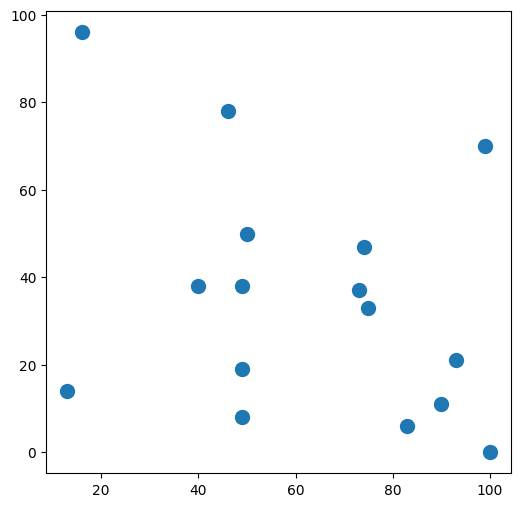

In [55]:
n = len(df)
depot = 0
nodes = [i for i in df['CUST_NO']]

plt.figure(figsize=(6,6))
X= [df.loc[n,'X'] for n in nodes]
Y= [df.loc[n,'Y'] for n in nodes]
plt.scatter(X,Y,s=100)


In [71]:
def distance(n:int,m:int,df:dict, t:str)-> int:
  x1,y1 = df.loc[n,'X'],  df.loc[n,'Y']
  x2,y2 = df.loc[m,'X'],  df.loc[m,'Y']
  if t == 'p1':
    coef = 1.2
  elif t == 'p2':
    coef = 0.6
  return int(1*coef*np.sqrt( (x1-x2)**2+(y1-y2)**2))

print(nodes)

for i in nodes:
  for j in nodes:
    for t in ['p1','p2']:
      print(i,j,t,distance(i,j,df,t))

KOLORS = ['r','k','b','g','gold','brown']
cap = {0:102, 1:95, 2:93, 3:73, 4:71}


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
0 0 p1 0
0 0 p2 0
0 1 p1 67
0 1 p2 33
0 2 p1 66
0 2 p2 33
0 3 p1 31
0 3 p2 15
0 4 p1 63
0 4 p2 31
0 5 p1 84
0 5 p2 42
0 6 p1 68
0 6 p2 34
0 7 p1 50
0 7 p2 25
0 8 p1 36
0 8 p2 18
0 9 p1 14
0 9 p2 7
0 10 p1 61
0 10 p2 30
0 11 p1 18
0 11 p2 9
0 12 p1 62
0 12 p2 31
0 13 p1 29
0 13 p2 14
0 14 p1 33
0 14 p2 16
0 15 p1 37
0 15 p2 18
1 0 p1 67
1 0 p2 33
1 1 p1 0
1 1 p2 0
1 2 p1 10
1 2 p2 5
1 3 p1 37
1 3 p2 18
1 4 p1 71
1 4 p2 35
1 5 p1 17
1 5 p2 8
1 6 p1 135
1 6 p2 67
1 7 p1 49
1 7 p2 24
1 8 p1 31
1 8 p2 15
1 9 p1 58
1 9 p2 29
1 10 p1 92
1 10 p2 46
1 11 p1 68
1 11 p2 34
1 12 p1 12
1 12 p2 6
1 13 p1 47
1 13 p2 23
1 14 p1 96
1 14 p2 48
1 15 p1 50
1 15 p2 25
2 0 p1 66
2 0 p2 33
2 1 p1 10
2 1 p2 5
2 2 p1 0
2 2 p2 0
2 3 p1 39
2 3 p2 19
2 4 p1 79
2 4 p2 39
2 5 p1 21
2 5 p2 10
2 6 p1 134
2 6 p2 67
2 7 p1 40
2 7 p2 20
2 8 p1 33
2 8 p2 16
2 9 p1 56
2 9 p2 28
2 10 p1 84
2 10 p2 42
2 11 p1 64
2 11 p2 32
2 12 p1 21
2 12 p2 10
2 13 p1 50
2 13 p2 25
2 1

0 102
1 95
2 93
3 73
4 71
Min of objective function: 157.0

0 0
0 1
0 2
0 3
0 4
1 1
2 1
3 2
4 3
5 1
6 0
7 2
8 2
9 0
10 4
11 4
12 1
13 3
14 0
15 2


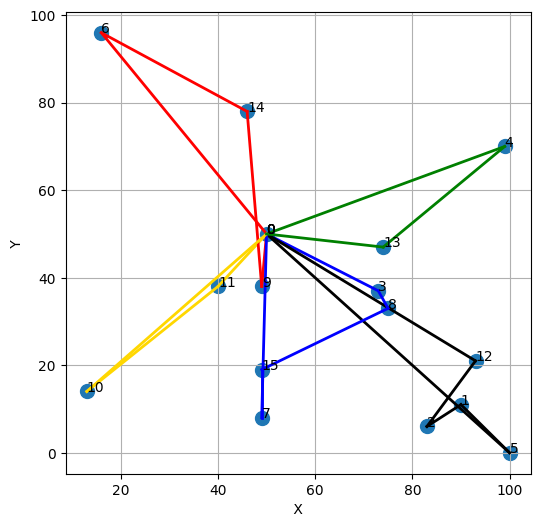

In [81]:
def main() -> None:
    # Creates the model.
    cap = {0:102, 1:95, 2:93, 3:73, 4:71}
    cars = [c for c in cap]

    times = {'p1':(0,300),
             'p2':(300+1,1000)}

    mint, maxt = int(min([a for p, (a,b) in times.items()])) , int(max([b for p, (a,b) in times.items()]) )

    model = cp_model.CpModel()
    x={(i,j,t,c):model.NewBoolVar(f"flow_{i}_{j}_{c}") for i in nodes
       for j in nodes for c in cars for t in times if i!=j}
    assign = {(i,c): model.NewBoolVar(f"assign_{i}_{c}") for i in nodes for c in cars}
    used_car = {c: model.NewBoolVar(f"used_{c}") for c in cars}

    arrive = {i: model.NewIntVar(df.loc[i,'ST'], df.loc[i,'DUE'], f"arrive_{i}") for i in nodes}

    model.add(arrive[depot] == mint )
    for i in nodes:
      expressions = [assign[i,c] for c in cars]
      if i == depot:
        model.AddAtLeastOne(expressions)
      else:
        model.AddExactlyOne(expressions)


    for (i,c),v in assign.items():
      model.Add(v<=used_car[c])

    for (i,j,t,cc),v in x.items():
      model.Add(v<=assign[i,cc])
      model.Add(v<=assign[j,cc])
      if j != depot:
        model.Add(arrive[j]>= arrive[i] + distance(i,j,df,t) + df.loc[i,'STIME']).OnlyEnforceIf(v)
        a, b = int(times[t][0]), int(times[t][1])
        model.Add(arrive[i] >= a).OnlyEnforceIf(v)
        model.Add(arrive[i] <= b - 1).OnlyEnforceIf(v)


    for c in cars:
      model.Add(assign[depot,c]==used_car[c])
      arcs= [ (i,j,v) for (i,j,t,cc),v in x.items() if cc == c] + [(i,i,assign[i,c].Not()) for i in nodes]
      model.AddCircuit(arcs)
      expressions = [v*df.loc[i,'D'] for (i,cc),v in assign.items() if c ==cc]
      model.Add(sum(expressions) <= cap[c])
      print(c,cap[c])

    expressions_of = [distance(i,j,df,t)* v for (i,j,t,c),v in x.items() ]
    #model.minimize(sum(expressions_of))

    finish_time = model.new_int_var(0,maxt,"finish time")
    for i,v in arrive.items():
      model.add(v<= finish_time)
    model.minimize(finish_time)


    # Creates a solver and solves the model.
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 90
    status = solver.solve(model)

    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print(f"Min of objective function: {solver.objective_value}\n")
        plt.figure(figsize=(6,6))
        X= [df.loc[n,'X'] for n in nodes]
        Y= [df.loc[n,'Y'] for n in nodes]
        plt.scatter(X,Y,s=100)

        for (i,c),v in assign.items():
          if solver.value(v)>0:
            print(i,c)

        for (i,j,t,c),v in x.items():
          if solver.value(v)>0:
            x1,y1 = df.loc[i,'X'],  df.loc[i,'Y']
            x2,y2 = df.loc[j,'X'],  df.loc[j,'Y']
            plt.plot([x1,x2],[y1,y2], lw=2, c=KOLORS[c])
            plt.text(x1,y1,s=str(i))

        plt.xlabel(' X ')
        plt.ylabel(' Y ')
        plt.grid()

        moves = []
        for (i, j, t, c), v in x.items():
            if solver.value(v) > 0:
                moves.append((c, t, i, j))



        return moves, solver, arrive

if __name__ == "__main__":
    out_moves, solver, arrive = main()

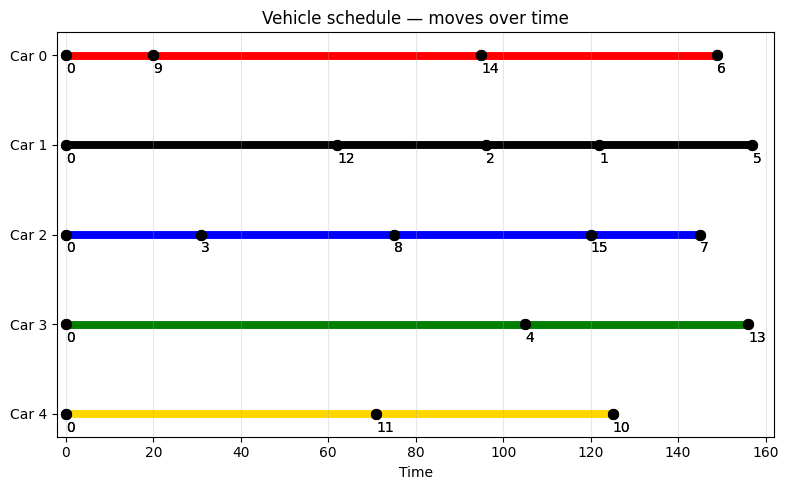

In [82]:
moves = out_moves
cars = [c for c in cap]

fig, ax = plt.subplots(figsize=(8, 0.6 * len(cars) + 2))

for c, t, i, j in moves:
    dur = distance(i, j, df, t)
    st = solver.Value(arrive[i])
    fn = solver.Value(arrive[j])

    ax.barh(y=c, width=fn-st, left=st,
            height=0.1, color=KOLORS[c],
            edgecolor='white', linewidth=0.8)
    # label the arc on the bar
    #ax.text(t + dur / 2, c, f"{i}→{j}",
    #        ha='center', va='center', fontsize=8, color='white')
    plt.scatter(st,c, s=50, color='k',zorder=2)
    plt.scatter(fn,c, s=50, color='k', zorder=2)
    plt.text(st,c+0.2,s=str(i))
    plt.text(fn,c+0.2,s=str(j))
ax.set_xlim(-2, solver.ObjectiveValue() + 5)

ax.set_yticks(cars)
ax.set_yticklabels([f"Car {c}" for c in cars])
ax.set_xlabel("Time")
ax.set_title("Vehicle schedule — moves over time")
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()               # Car 0 on top
plt.tight_layout()
plt.show()

In [60]:
out_moves

[(2, 'p1', 0, 3),
 (1, 'p1', 0, 5),
 (4, 'p1', 0, 6),
 (3, 'p1', 0, 8),
 (0, 'p1', 0, 9),
 (0, 'p1', 1, 0),
 (1, 'p1', 2, 0),
 (2, 'p1', 3, 4),
 (2, 'p1', 4, 0),
 (1, 'p1', 5, 2),
 (4, 'p1', 6, 14),
 (4, 'p1', 7, 0),
 (3, 'p1', 8, 13),
 (0, 'p1', 9, 11),
 (0, 'p1', 10, 15),
 (0, 'p1', 11, 10),
 (3, 'p1', 12, 0),
 (3, 'p1', 13, 12),
 (4, 'p1', 14, 7),
 (0, 'p2', 15, 1)]